# Lab | Convolutional Neural Networks

CIFAR-10 — 32×32 colour images, 10 classes. We'll build CNNs from scratch in PyTorch, track shapes, train a classifier, and measure data augmentation.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print(f"Using device: {device}")

Using device: cpu


---
## Task 1 — Convolution Mechanics: Filters and Shapes
### Part A — Handcrafted Filters

In [2]:
# Download CIFAR-10 and grab a single image
plain_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

cifar_train_raw = datasets.CIFAR10(root="./data", train=True, download=True, transform=plain_tf)
img_tensor, label = cifar_train_raw[0]          # shape: (3, 32, 32)
img_4d = img_tensor.unsqueeze(0)                # shape: (1, 3, 32, 32)

CIFAR10_CLASSES = ["airplane","automobile","bird","cat","deer",
                   "dog","frog","horse","ship","truck"]
print(f"Image shape: {img_4d.shape}  |  Label: {CIFAR10_CLASSES[label]}")

  0%|          | 0.00/170M [00:00<?, ?B/s]

  0%|          | 32.8k/170M [00:00<28:53, 98.4kB/s]

  0%|          | 98.3k/170M [00:00<13:22, 212kB/s] 

  0%|          | 197k/170M [00:00<08:22, 339kB/s] 

  0%|          | 328k/170M [00:00<06:00, 472kB/s]

...

100%|█████████▉| 170M/170M [01:34<00:00, 1.75MB/s]

100%|█████████▉| 170M/170M [01:34<00:00, 1.60MB/s]

100%|██████████| 170M/170M [01:34<00:00, 1.81MB/s]

Image shape: torch.Size([1, 3, 32, 32])  |  Label: frog


C:\Users\narim\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


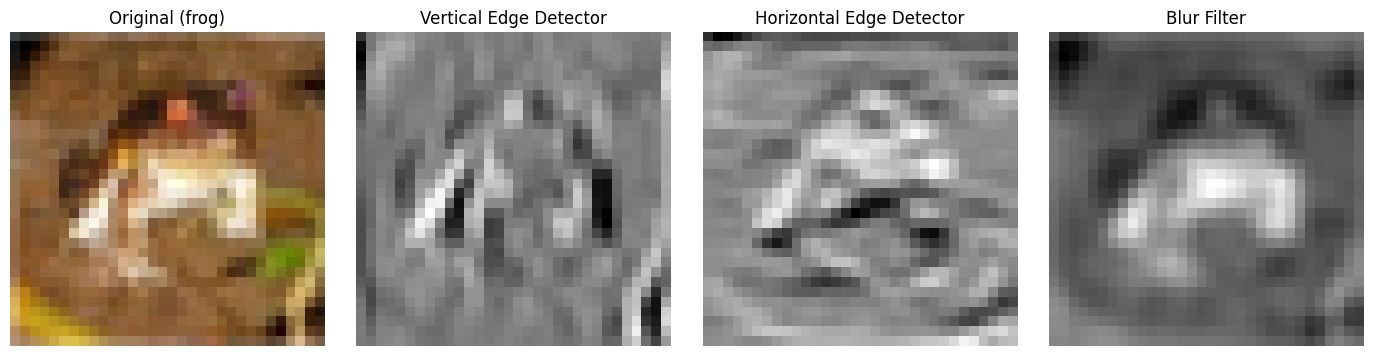

In [3]:
def make_conv(weights_hw: np.ndarray) -> nn.Conv2d:
    """Create a (3→1) Conv2d with identical weights across all input channels."""
    conv = nn.Conv2d(3, 1, kernel_size=3, padding=1, bias=False)
    w = torch.tensor(weights_hw, dtype=torch.float32)
    # shape needed: (out_channels=1, in_channels=3, kH=3, kW=3)
    conv.weight = nn.Parameter(w.unsqueeze(0).unsqueeze(0).repeat(1, 3, 1, 1))
    return conv

vert_kernel  = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
horiz_kernel = vert_kernel.T
blur_kernel  = np.ones((3, 3), dtype=np.float32) / 9.0

conv_vert  = make_conv(vert_kernel)
conv_horiz = make_conv(horiz_kernel)
conv_blur  = make_conv(blur_kernel)

with torch.no_grad():
    out_vert  = conv_vert(img_4d).squeeze()   # (32, 32)
    out_horiz = conv_horiz(img_4d).squeeze()
    out_blur  = conv_blur(img_4d).squeeze()

# Undo normalisation for display
img_display = img_tensor.permute(1, 2, 0).numpy() * 0.5 + 0.5
img_display = np.clip(img_display, 0, 1)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes[0].imshow(img_display)
axes[0].set_title(f"Original ({CIFAR10_CLASSES[label]})")
axes[1].imshow(out_vert.numpy(),  cmap="gray")
axes[1].set_title("Vertical Edge Detector")
axes[2].imshow(out_horiz.numpy(), cmap="gray")
axes[2].set_title("Horizontal Edge Detector")
axes[3].imshow(out_blur.numpy(),  cmap="gray")
axes[3].set_title("Blur Filter")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.savefig("task1a_filters.png", dpi=120)
plt.show()

### Filter Descriptions

| Filter | What it highlights |
|--------|--------------------|
| **Vertical edge detector** `[[-1,0,1],[-1,0,1],[-1,0,1]]` | Responds to abrupt left→right brightness changes; lights up vertical boundaries such as the sides of objects. |
| **Horizontal edge detector** (transpose of vertical) | Responds to abrupt top→bottom brightness changes; highlights horizontal boundaries like the tops/bottoms of objects. |
| **Blur** `(1/9)*ones(3,3)` | Averages each pixel with its 8 neighbours; smooths the image and suppresses high-frequency noise or texture. |

### Part B — Shape Tracking

In [4]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

x = torch.randn(8, 3, 32, 32)
print(f"Input :  {tuple(x.shape)}")

tiny = TinyCNN()
with torch.no_grad():
    x1 = tiny.conv1(x);  print(f"conv1  : {tuple(x1.shape)}")
    x2 = tiny.pool1(x1); print(f"pool1  : {tuple(x2.shape)}")
    x3 = tiny.conv2(x2); print(f"conv2  : {tuple(x3.shape)}")
    x4 = tiny.pool2(x3); print(f"pool2  : {tuple(x4.shape)}")

Input :  (8, 3, 32, 32)
conv1  : (8, 16, 32, 32)
pool1  : (8, 16, 16, 16)
conv2  : (8, 32, 16, 16)
pool2  : (8, 32, 8, 8)


### Shape-Tracking Table

| Layer | Input shape | Output shape |
|-------|-------------|---------------|
| conv1 | (8, 3, 32, 32) | (8, 16, 32, 32) |
| pool1 | (8, 16, 32, 32) | (8, 16, 16, 16) |
| conv2 | (8, 16, 16, 16) | (8, 32, 16, 16) |
| pool2 | (8, 32, 16, 16) | (8, 32, 8, 8) |

Each `Conv2d(k=3, p=1)` preserves spatial size. Each `MaxPool2d(2)` halves spatial dimensions.

---
## Task 2 — Train a Small CNN on CIFAR-10 (No Augmentation)

In [5]:
# Data loaders — plain transforms only
plain_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

train_set_plain = datasets.CIFAR10(root="./data", train=True,  download=False, transform=plain_transform)
val_set         = datasets.CIFAR10(root="./data", train=False, download=False, transform=plain_transform)

train_loader_plain = DataLoader(train_set_plain, batch_size=128, shuffle=True,  num_workers=0, pin_memory=False)
val_loader         = DataLoader(val_set,         batch_size=256, shuffle=False, num_workers=0, pin_memory=False)

print(f"Train batches: {len(train_loader_plain)}  |  Val batches: {len(val_loader)}")

Train batches: 391  |  Val batches: 40


In [6]:
class CIFARCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 32x32 → 16x16
        )
        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),          # 16x16 → 8x8
        )
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        return self.classifier(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

model_plain = CIFARCNN().to(device)
print(f"Trainable parameters: {count_params(model_plain):,}")

Trainable parameters: 1,117,354


In [7]:
def train_model(model, train_loader, val_loader, epochs=15, lr=1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        # --- Training ---
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            correct += (logits.argmax(1) == labels).sum().item()
            total   += imgs.size(0)
        train_loss = running_loss / total
        train_acc  = correct / total

        # --- Validation ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                logits = model(imgs)
                loss = criterion(logits, labels)
                val_loss    += loss.item() * imgs.size(0)
                val_correct += (logits.argmax(1) == labels).sum().item()
                val_total   += imgs.size(0)
        val_loss /= val_total
        val_acc   = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train loss: {train_loss:.4f}  acc: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f}  acc: {val_acc:.4f}")

    return history


print("Training Task 2 model (no augmentation)...")
history_plain = train_model(model_plain, train_loader_plain, val_loader, epochs=15)

Training Task 2 model (no augmentation)...


Epoch 01/15 | Train loss: 1.4497  acc: 0.4763 | Val loss: 1.0862  acc: 0.6060


Epoch 02/15 | Train loss: 0.9917  acc: 0.6458 | Val loss: 0.9296  acc: 0.6731


Epoch 03/15 | Train loss: 0.8344  acc: 0.7052 | Val loss: 0.7541  acc: 0.7325


Epoch 04/15 | Train loss: 0.7362  acc: 0.7404 | Val loss: 0.7499  acc: 0.7377


...

Epoch 11/15 | Train loss: 0.4171  acc: 0.8503 | Val loss: 0.6662  acc: 0.7803


Epoch 12/15 | Train loss: 0.3875  acc: 0.8591 | Val loss: 0.6571  acc: 0.7903


Epoch 13/15 | Train loss: 0.3584  acc: 0.8694 | Val loss: 0.6348  acc: 0.7986


Epoch 14/15 | Train loss: 0.3272  acc: 0.8807 | Val loss: 0.6913  acc: 0.7893


Epoch 15/15 | Train loss: 0.3069  acc: 0.8883 | Val loss: 0.6479  acc: 0.7976


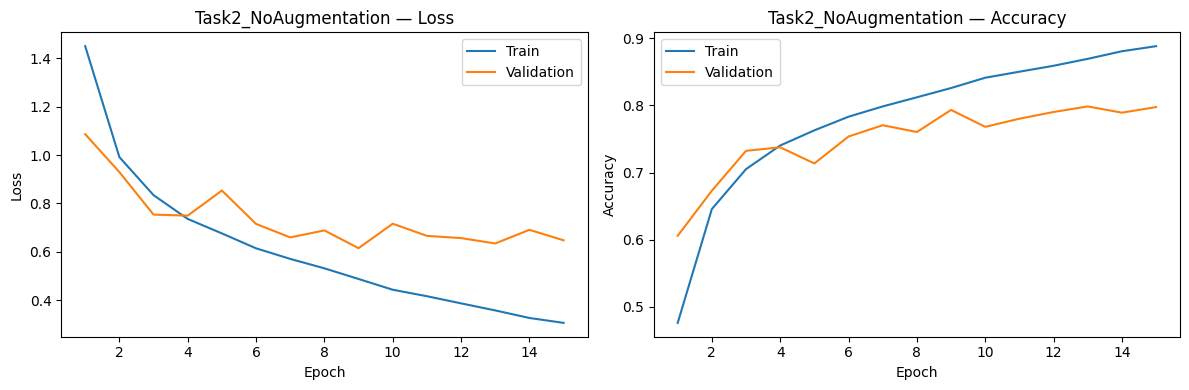


Task 2 best val accuracy: 0.7986 at epoch 13
Train/val gap at best epoch: 0.0708


In [8]:
def plot_history(history, title="Training Curves"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history["train_loss"], label="Train")
    ax1.plot(epochs, history["val_loss"],   label="Validation")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.set_title(f"{title} — Loss")
    ax1.legend()

    ax2.plot(epochs, history["train_acc"], label="Train")
    ax2.plot(epochs, history["val_acc"],   label="Validation")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{title} — Accuracy")
    ax2.legend()

    plt.tight_layout()
    plt.savefig(f"{title.replace(' ', '_')}.png", dpi=120)
    plt.show()

plot_history(history_plain, "Task2_NoAugmentation")

best_val_plain = max(history_plain["val_acc"])
best_epoch_plain = history_plain["val_acc"].index(best_val_plain) + 1
gap_plain = history_plain["train_acc"][best_epoch_plain - 1] - best_val_plain
print(f"\nTask 2 best val accuracy: {best_val_plain:.4f} at epoch {best_epoch_plain}")
print(f"Train/val gap at best epoch: {gap_plain:.4f}")

---
## Task 3 — Data Augmentation

In [9]:
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

train_set_aug    = datasets.CIFAR10(root="./data", train=True,  download=False, transform=train_tf)
train_loader_aug = DataLoader(train_set_aug, batch_size=128, shuffle=True, num_workers=0, pin_memory=False)

model_aug = CIFARCNN().to(device)
print(f"Trainable parameters: {count_params(model_aug):,}")
print("Training Task 3 model (with augmentation)...")
history_aug = train_model(model_aug, train_loader_aug, val_loader, epochs=15)

Trainable parameters: 1,117,354
Training Task 3 model (with augmentation)...


Epoch 01/15 | Train loss: 1.6186  acc: 0.4077 | Val loss: 1.2231  acc: 0.5570


Epoch 02/15 | Train loss: 1.2063  acc: 0.5659 | Val loss: 1.0149  acc: 0.6365


Epoch 03/15 | Train loss: 1.0450  acc: 0.6280 | Val loss: 0.8233  acc: 0.7070


Epoch 04/15 | Train loss: 0.9527  acc: 0.6658 | Val loss: 0.7845  acc: 0.7271


...

Epoch 11/15 | Train loss: 0.7206  acc: 0.7498 | Val loss: 0.6959  acc: 0.7636


Epoch 12/15 | Train loss: 0.7066  acc: 0.7551 | Val loss: 0.6662  acc: 0.7751


Epoch 13/15 | Train loss: 0.6837  acc: 0.7633 | Val loss: 0.6025  acc: 0.7929


Epoch 14/15 | Train loss: 0.6676  acc: 0.7716 | Val loss: 0.5512  acc: 0.8097


Epoch 15/15 | Train loss: 0.6549  acc: 0.7735 | Val loss: 0.5975  acc: 0.7957


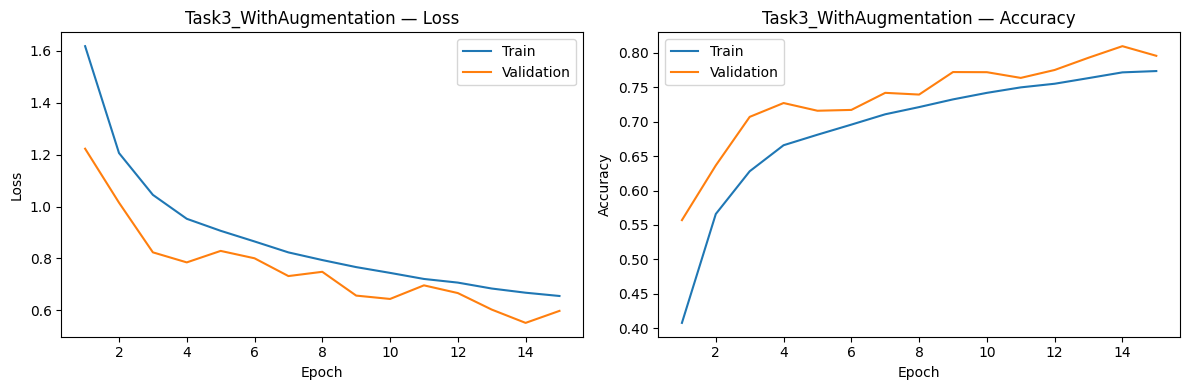


Task 3 best val accuracy: 0.8097 at epoch 14
Train/val gap at best epoch: -0.0381


In [10]:
plot_history(history_aug, "Task3_WithAugmentation")

best_val_aug = max(history_aug["val_acc"])
best_epoch_aug = history_aug["val_acc"].index(best_val_aug) + 1
gap_aug = history_aug["train_acc"][best_epoch_aug - 1] - best_val_aug
print(f"\nTask 3 best val accuracy: {best_val_aug:.4f} at epoch {best_epoch_aug}")
print(f"Train/val gap at best epoch: {gap_aug:.4f}")

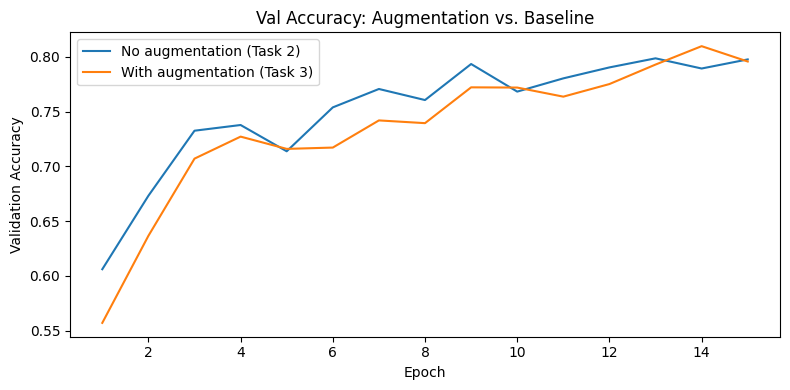


=== Comparison Table ===
Run                                   Best val acc  Train/val gap
-----------------------------------------------------------------
Task 2 (no augmentation)                    0.7986         0.0708
Task 3 (with augmentation)                  0.8097        -0.0381


In [11]:
# Side-by-side accuracy curves
epochs = range(1, 16)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, history_plain["val_acc"], label="No augmentation (Task 2)")
ax.plot(epochs, history_aug["val_acc"],   label="With augmentation (Task 3)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Validation Accuracy")
ax.set_title("Val Accuracy: Augmentation vs. Baseline")
ax.legend()
plt.tight_layout()
plt.savefig("task3_comparison.png", dpi=120)
plt.show()

print("\n=== Comparison Table ===")
print(f"{'Run':<35} {'Best val acc':>14} {'Train/val gap':>14}")
print("-" * 65)
print(f"{'Task 2 (no augmentation)':<35} {best_val_plain:>14.4f} {gap_plain:>14.4f}")
print(f"{'Task 3 (with augmentation)':<35} {best_val_aug:>14.4f} {gap_aug:>14.4f}")

### Augmentation Results

| Run | Best val accuracy | Train/val gap |
|-----|:-----------------:|:-------------:|
| Task 2 (no augmentation) | **79.86%** | 7.08% |
| Task 3 (with augmentation) | **80.97%** | -3.81% |

**Interpretation:**

- **Validation accuracy** typically improves with augmentation because the model sees more diverse training examples, making it less likely to memorise specific pixel patterns.
- **Train/val gap** (overfitting proxy) shrinks with augmentation: because training accuracy is harder to inflate when each epoch presents slightly different versions of the same image, the model learns more generalisable features rather than fitting exact training images.
- `RandomCrop` forces the model to localise objects regardless of position. `RandomHorizontalFlip` exploits left-right symmetry. `ColorJitter` adds robustness to lighting changes — all mimicking real-world variability the model would face at test time.